In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")

import matplotlib.pyplot as plt
import numpy as np
import random
import os
import networkx as nx

from src.graphs import StaticGraph, DynamicGraph, IntersectingEdgesGraph, MultiEdgeGraph
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, SparsePauliOp, Pauli
from scipy.linalg import expm
import itertools

from IPython.display import display

In [3]:

def graph_to_bitstring_edges(graph):
    # Number of nodes in the graph
    num_nodes = len(graph.nodes)

    # Determine how many bits are needed for each node (based on the number of nodes)
    num_bits = len(bin(num_nodes - 1)) - 2  # bin(x) gives '0bxxx', so we subtract 2

    # Create a mapping of node to bit string
    node_to_bitstring = {node: format(node, f'0{num_bits}b') for node in graph.nodes}

    # Convert edges to the new format
    edges_bitstring = {(node_to_bitstring[u], node_to_bitstring[v]) for u, v in graph.edges}

    return edges_bitstring


#g6 = f'./../data/graphs/graph4c.g6'

n_vertex = 16

g6 = f'./../data/graphs/graph{n_vertex}c.g6'

graph_edges = []

# Open and read the .g6 file line by line
with open(g6, 'r') as file:
    for line in file:
        g6_string = line.strip()
        try:
            # Convert the graph6 string into a NetworkX graph
            graph = nx.from_graph6_bytes(g6_string.encode('utf-8'))
            
            # Convert the graph edges to bit string format
            bitstring_edges = graph_to_bitstring_edges(graph)
            
            # Output the result
            #print(bitstring_edges)
            graph_edges.append(bitstring_edges)
            G = StaticGraph(bitstring_edges)
            # display(G.draw())  
        except nx.NetworkXError as e:
            print(f"Error: {e}")

In [4]:
def unitary_to_pauli(U):
    n = int(np.log2(U.shape[0]))
    dim = 2**n
    pauli_strings = []
    coeffs = []
    for pauli_string in [''.join(p) for p in itertools.product('IXYZ', repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ U) / dim
        if not np.isclose(coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(coeff)
    return SparsePauliOp(pauli_strings, coeffs)

def construct_time_evolution_matrix(pauli_terms, delta_t):
    matrix = Operator(pauli_terms).data
    exponent = -1j * delta_t * matrix
    return Operator(expm(exponent))

def count_gates_dynamic_walk(edges, T, delta_t):
    G = StaticGraph(edges)
    graph_sequence = [(G, T)]
    dyn_G = DynamicGraph(graph_sequence)
    intersecting_G = IntersectingEdgesGraph(edges)
    graph_sequence = [(graph, delta_t) for graph in intersecting_G.subgraphs]
    dyn_G_approx = DynamicGraph(graph_sequence)
    
    big_qc = QuantumCircuit(G.n_qubits)
    for sq in dyn_G_approx.graph_sequence:
        G = MultiEdgeGraph(sq[0].edges)
        sub_qc = G.get_qc(simplified=True)
        big_qc = big_qc.compose(sub_qc)
    
    # transpiled_qc = min([transpile(big_qc, basis_gates=['cx', 'u3'], optimization_level=3) 
    #                 for _ in range(10)], 
    #                key=lambda c: c.count_ops()['cx'])
    transpiled_qc = transpile(big_qc, basis_gates=['cx', 'u3'], optimization_level=3, seed_transpiler=42)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()

def count_gates_pauli_decomp(edges, delta_t):
    G = StaticGraph(edges)
    pauli_terms = unitary_to_pauli(G.get_adj_mat())
    evo_matrix_from_pauli = construct_time_evolution_matrix(pauli_terms, delta_t)
    
    qc = QuantumCircuit(G.n_qubits)
    qc.unitary(evo_matrix_from_pauli, range(G.n_qubits), label='Evo')
    
    # transpiled_qc = min([transpile(qc, basis_gates=['cx', 'u3'], optimization_level=3) 
    #                 for _ in range(10)], 
    #                key=lambda c: c.count_ops()['cx'])
    transpiled_qc = transpile(qc, basis_gates=['cx', 'u3'], optimization_level=3, seed_transpiler=42)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()


In [ ]:
T = 200
delta_t = 0.1

results = []
error_graphs = []

for i, edges in enumerate(graph_edges):
    try:
        dynamic_cx, dynamic_u3, dynamic_depth = count_gates_dynamic_walk(edges, T, delta_t)
        pauli_cx, pauli_u3, pauli_depth = count_gates_pauli_decomp(edges, delta_t)
        
        dynamic_total = dynamic_cx + dynamic_u3
        pauli_total = pauli_cx + pauli_u3
        difference = dynamic_total - pauli_total
        
        results.append({
            'Graph': i,
            'Dynamic': dynamic_total,
            'Pauli': pauli_total,
            'Difference': difference,
            'Edges': edges
        })
        
        ##print(f"Graph {i+1}: Total gates - Dynamic: {dynamic_total}, Pauli: {pauli_total}, Difference: {difference}")
    except Exception as e:
        #print(f"Error in Graph {i+1}: {str(e)}")
        error_graphs.append((i, edges))



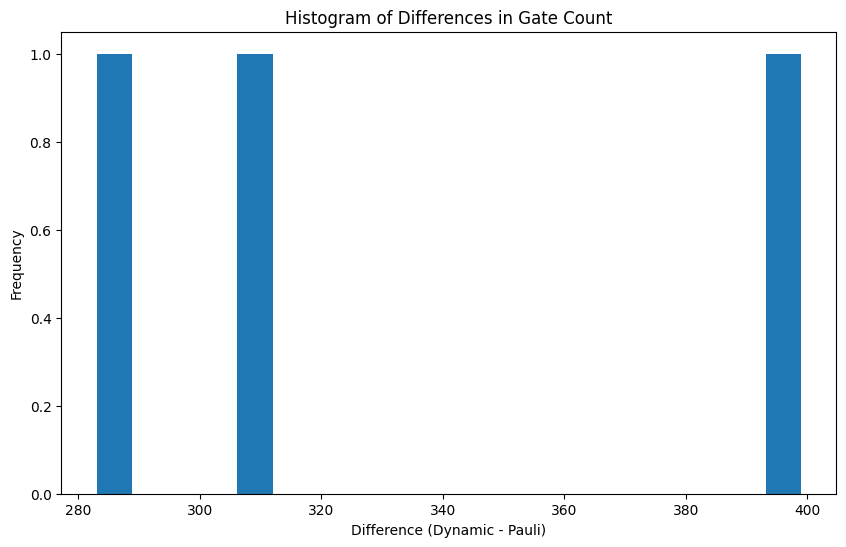

In [ ]:
differences = [r['Difference'] for r in results]
plt.figure(figsize=(10, 6))
plt.hist(differences, bins=20)
plt.title('Histogram of Differences in Gate Count')
plt.xlabel('Difference (Dynamic - Pauli)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Classify graphs
positive_graphs = [r for r in results if r['Difference'] > 0]
negative_graphs = [r for r in results if r['Difference'] < 0]
zero_graphs = [r for r in results if r['Difference'] == 0]

# Function to save graphs in G6 format
def save_graphs(graphs, filename):
    with open(filename, 'w') as f:
        for graph in graphs:
            G = nx.Graph(graph['Edges'])
            g6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
            f.write(f"{g6_string}\n")

# Save classified graphs
save_graphs(positive_graphs, f'../data/graphs/positive_{n_vertex}cgraphs.g6')
save_graphs(negative_graphs, f'../data/graphs/negative_{n_vertex}cgraphs.g6')
save_graphs(zero_graphs, f'../data/graphs/zero_{n_vertex}cgraphs.g6')

# Save error graphs
with open(f'../data/graphs/error_{n_vertex}cgraphs.g6', 'w') as f:
    for _, edges in error_graphs:
        G = nx.Graph(edges)
        g6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
        f.write(f"{g6_string}\n")

In [5]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

def count_graphs(filename):
    count = 0
    with open(filename, 'r') as file:
        for line in file:
            if line.strip():
                count += 1
    return count

def visualize_random_graphs(filename, num_graphs=5):
    graph_edges = []
    
    with open(filename, 'r') as file:
        g6_strings = file.readlines()
    
    if len(g6_strings) < num_graphs:
        num_graphs = len(g6_strings)
    
    random_g6_strings = random.sample(g6_strings, num_graphs)
    
    for g6_string in random_g6_strings:
        try:
            graph = nx.from_graph6_bytes(g6_string.strip().encode('utf-8'))
            bitstring_edges = graph_to_bitstring_edges(graph)
            G = StaticGraph(bitstring_edges)
            display(G.draw())
        except nx.NetworkXError as e:
            print(f"Error: {e}")


Analyzing graphs from positive_16cgraphs.g6
Number of graphs: 3
Percentage of original: 42.86%
Visualizing 5 random graphs:


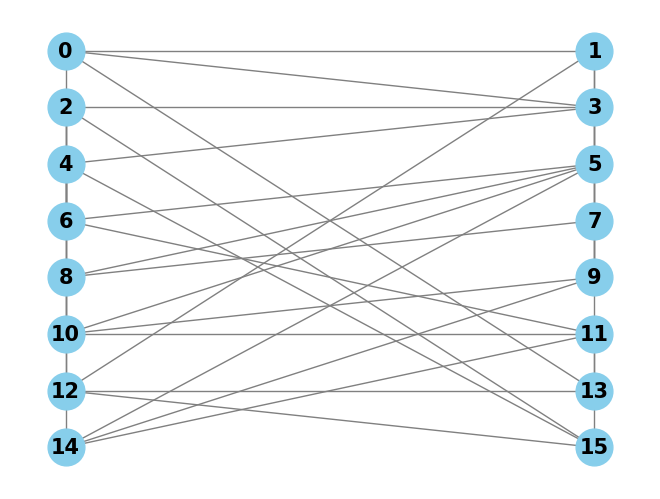

None

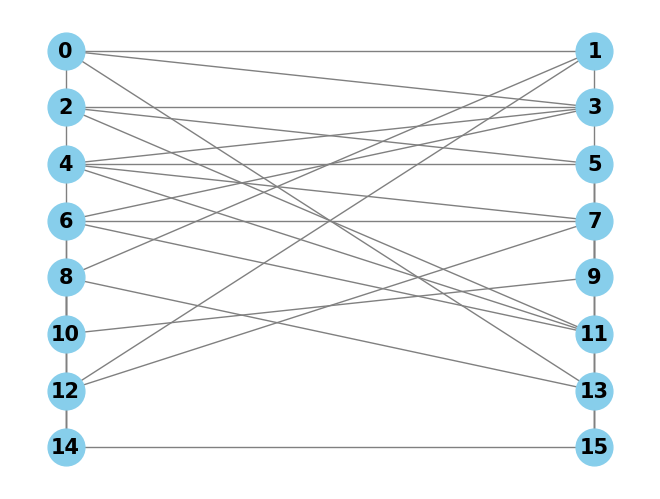

None

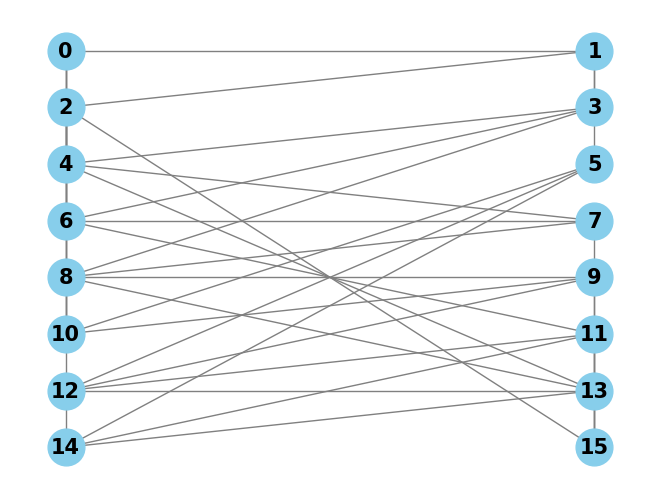

None


Analyzing graphs from negative_16cgraphsc.g6

Analyzing graphs from error_16cgraphs.g6
Number of graphs: 4
Percentage of original: 57.14%
Visualizing 5 random graphs:


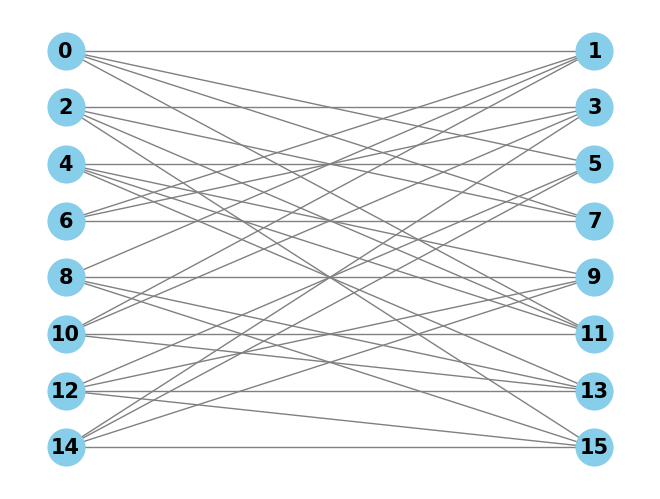

None

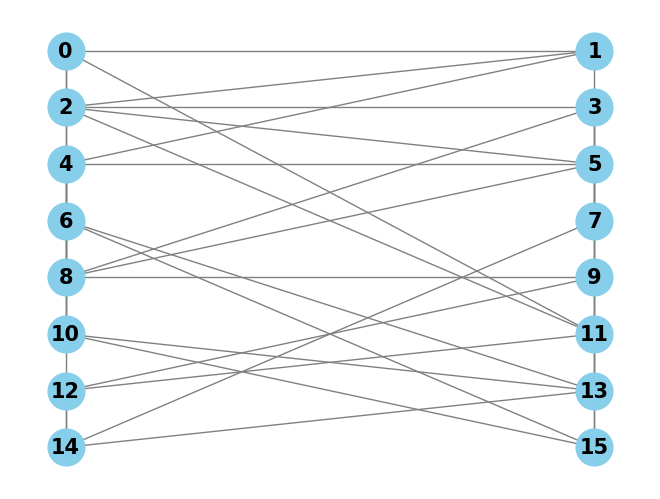

None

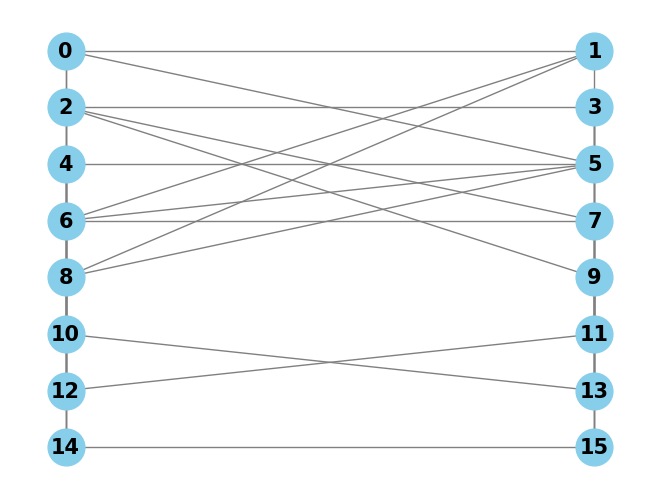

None

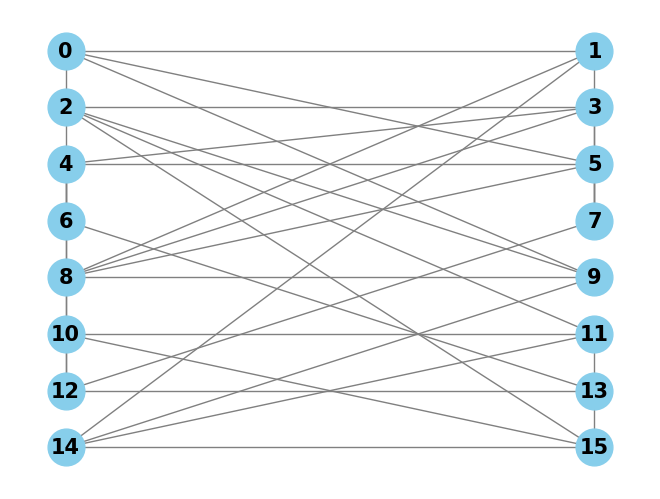

None

In [ ]:
# Count graphs in the original file
original_file = f'./../data/graphs/graph{n_vertex}c.g6'
original_count = count_graphs(original_file)

# Visualize and count graphs for each file
files = [f'positive_{n_vertex}cgraphs.g6', f'negative_{n_vertex}cgraphsc.g6', f'zero_{n_vertex}cgraphs.g6', f'error_{n_vertex}cgraphs.g6']
for filename in files:
    try:
        full_path = os.path.join('../data/graphs', filename)
        print(f"\nAnalyzing graphs from {filename}")
        
        # Count graphs
        graph_count = count_graphs(full_path)
        percentage = (graph_count / original_count) * 100
        
        print(f"Number of graphs: {graph_count}")
        print(f"Percentage of original: {percentage:.2f}%")
        
        # Visualize random graphs
        print("Visualizing 5 random graphs:")
        visualize_random_graphs(full_path)
    except: 
        files.remove(filename)
        continue

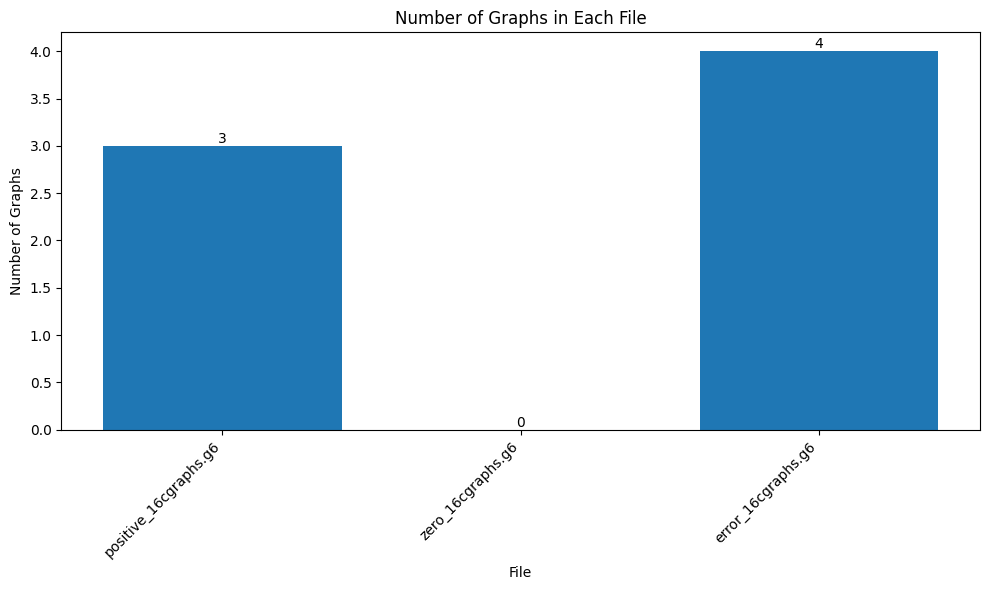

In [ ]:
# Create a bar plot of graph counts
counts = [count_graphs(os.path.join('../data/graphs', f)) for f in files]
plt.figure(figsize=(10, 6))
plt.bar(files, counts)
plt.title('Number of Graphs in Each File')
plt.xlabel('File')
plt.ylabel('Number of Graphs')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

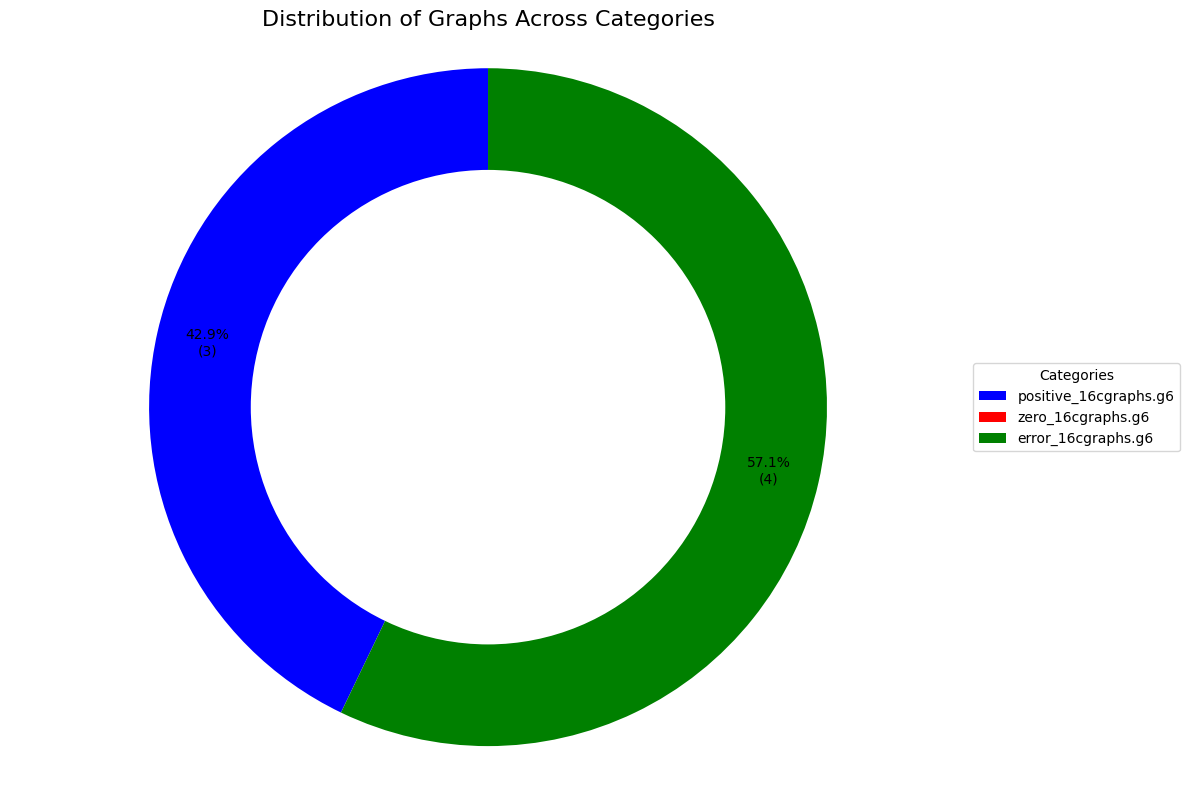

In [ ]:
# Create a pie chart of percentages
percentages = [(count / original_count) * 100 for count in counts]
labels = [f.replace('_graphs.g6', '') for f in files]  # Simplify labels

plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'black']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:d})' if pct > 1 else ''
    return my_autopct

wedges, texts, autotexts = plt.pie(percentages, colors=colors, 
                                   autopct=make_autopct(counts),
                                   startangle=90, pctdistance=0.85)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Graphs Across Categories', fontsize=16)
plt.axis('equal')

# Add legend
plt.legend(wedges, labels,
           title="Categories",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [ ]:
import sys
import os
import gc
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Set, Tuple, Dict, List
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, SparsePauliOp, Pauli
from scipy.linalg import expm
import itertools
import psutil
import warnings
from tqdm import tqdm

class MemoryTracker:
    @staticmethod
    def get_memory_usage():
        process = psutil.Process(os.getpid())
        return process.memory_info().rss / 1024 / 1024  # MB
    
    @staticmethod
    def clear_memory():
        gc.collect()
        if sys.platform == 'win32':
            import ctypes
            ctypes.windll.kernel32.SetProcessWorkingSetSize(-1, -1)

def unitary_to_pauli(U):
    """Convert unitary matrix to Pauli operators"""
    n = int(np.log2(U.shape[0]))
    dim = 2**n
    pauli_strings = []
    coeffs = []
    for pauli_string in [''.join(p) for p in itertools.product('IXYZ', repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ U) / dim
        if not np.isclose(coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(coeff)
    return SparsePauliOp(pauli_strings, coeffs)

def construct_time_evolution_matrix(pauli_terms, delta_t):
    """Construct time evolution matrix from Pauli terms"""
    matrix = Operator(pauli_terms).data
    exponent = -1j * delta_t * matrix
    return Operator(expm(exponent))

class GraphAnalyzer:
    def __init__(self, n_vertex: int = 16, batch_size: int = 1):
        self.n_vertex = n_vertex
        self.batch_size = batch_size
        self.memory_tracker = MemoryTracker()
        self.error_graphs = []
        self.T = 200
        self.delta_t = 0.1
        self.setup_directories()
        
        # Reduce matplotlib memory usage
        plt.rcParams['figure.dpi'] = 100
        plt.rcParams['savefig.dpi'] = 100
        warnings.filterwarnings('ignore')
    
    def setup_directories(self):
        """Create necessary directories"""
        dirs = ['../data/graphs', '../data/processed', 
                '../data/results', '../data/visualizations']
        for dir_path in dirs:
            Path(dir_path).mkdir(parents=True, exist_ok=True)
    
    def count_gates_dynamic_walk(self, edges, T, delta_t):
        """Count gates using dynamic walk approach"""
        try:
            from src.graphs import StaticGraph, DynamicGraph, IntersectingEdgesGraph, MultiEdgeGraph
            
            G = StaticGraph(edges)
            graph_sequence = [(G, T)]
            dyn_G = DynamicGraph(graph_sequence)
            intersecting_G = IntersectingEdgesGraph(edges)
            graph_sequence = [(graph, delta_t) for graph in intersecting_G.subgraphs]
            dyn_G_approx = DynamicGraph(graph_sequence)
            
            big_qc = QuantumCircuit(G.n_qubits)
            for sq in dyn_G_approx.graph_sequence:
                G = MultiEdgeGraph(sq[0].edges)
                sub_qc = G.get_qc(simplified=True)
                big_qc = big_qc.compose(sub_qc)
            
            transpiled_qc = transpile(big_qc, basis_gates=['cx', 'u3'], 
                                    optimization_level=3, seed_transpiler=42)
            gate_counts = transpiled_qc.count_ops()
            
            # Clear memory
            del G, dyn_G, intersecting_G, dyn_G_approx, big_qc, transpiled_qc
            self.memory_tracker.clear_memory()
            
            return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()
            
        except Exception as e:
            print(f"\nError in dynamic walk: {str(e)}")
            return 0, 0, 0
    
    def count_gates_pauli_decomp(self, edges, delta_t):
        """Count gates using Pauli decomposition approach"""
        try:
            from src.graphs import StaticGraph
            
            G = StaticGraph(edges)
            pauli_terms = unitary_to_pauli(G.get_adj_mat())
            evo_matrix_from_pauli = construct_time_evolution_matrix(pauli_terms, delta_t)
            
            qc = QuantumCircuit(G.n_qubits)
            qc.unitary(evo_matrix_from_pauli, range(G.n_qubits), label='Evo')
            
            transpiled_qc = transpile(qc, basis_gates=['cx', 'u3'], 
                                    optimization_level=3, seed_transpiler=42)
            gate_counts = transpiled_qc.count_ops()
            
            # Clear memory
            del G, pauli_terms, evo_matrix_from_pauli, qc, transpiled_qc
            self.memory_tracker.clear_memory()
            
            return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()
            
        except Exception as e:
            print(f"\nError in Pauli decomposition: {str(e)}")
            return 0, 0, 0
    
    def process_graph(self, graph_data: Tuple[int, str]) -> Dict:
        """Process a single graph and count gates"""
        index, g6_string = graph_data
        try:
            # Convert g6 to graph
            graph = nx.from_graph6_bytes(g6_string.strip().encode('utf-8'))
            
            # Convert to bitstring representation
            num_bits = len(bin(len(graph.nodes) - 1)) - 2
            node_to_bitstring = {node: format(node, f'0{num_bits}b') 
                               for node in graph.nodes}
            edges = {(node_to_bitstring[u], node_to_bitstring[v]) 
                    for u, v in graph.edges}
            
            # Count gates
            dynamic_cx, dynamic_u3, dynamic_depth = self.count_gates_dynamic_walk(edges, self.T, self.delta_t)
            pauli_cx, pauli_u3, pauli_depth = self.count_gates_pauli_decomp(edges, self.delta_t)
            
            dynamic_total = dynamic_cx + dynamic_u3
            pauli_total = pauli_cx + pauli_u3
            difference = dynamic_total - pauli_total
            
            result = {
                'Graph': index,
                'Dynamic': dynamic_total,
                'Pauli': pauli_total,
                'Difference': difference,
                'Edges': list(edges)
            }
            
            # Clear memory
            del graph, node_to_bitstring
            self.memory_tracker.clear_memory()
            
            return result
            
        except Exception as e:
            print(f"\nError processing graph {index}: {str(e)}")
            self.error_graphs.append((index, edges))
            return None
    
    def analyze_graphs(self):
        """Main analysis function"""
        print("\nStarting Graph Analysis:")
        input_file = Path(f'../data/graphs/graph{self.n_vertex}c.g6')
        
        if not input_file.exists():
            print(f"Input file not found: {input_file}")
            return
        
        results = []
        
        # Count total graphs
        with open(input_file, 'r') as f:
            total_graphs = sum(1 for _ in f)
        
        # Process graphs
        with open(input_file, 'r') as f:
            for i, line in tqdm(enumerate(f), total=total_graphs, 
                              desc="Processing graphs"):
                if not line.strip():
                    continue
                
                result = self.process_graph((i, line))
                if result:
                    results.append(result)
                
                # Save intermediate results periodically
                if i % 5 == 0:
                    self.save_results(results, is_final=False)
                    mem_usage = self.memory_tracker.get_memory_usage()
                    print(f"\rMemory usage: {mem_usage:.1f} MB", end="")
        
        # Save final results
        self.save_results(results, is_final=True)
        self.create_visualizations(results)
    
    def save_results(self, results: List[Dict], is_final: bool = False):
        """Save results and error graphs"""
        # Categorize results
        categorized = {
            'positive': [],
            'negative': [],
            'zero': []
        }
        
        for result in results:
            if result['Difference'] > 0:
                categorized['positive'].append(result)
            elif result['Difference'] < 0:
                categorized['negative'].append(result)
            else:
                categorized['zero'].append(result)
        
        # Save results
        output_file = Path('../data/results') / ('final_results.json' if is_final else 'intermediate_results.json')
        with open(output_file, 'w') as f:
            json.dump({
                'results': results,
                'error_graphs': self.error_graphs,
                'categories': categorized
            }, f)
        
        # Save graph categories in g6 format
        if is_final:
            for category, category_results in categorized.items():
                if category_results:
                    with open(f'../data/graphs/{category}_{self.n_vertex}cgraphs.g6', 'w') as f:
                        for result in category_results:
                            graph = nx.Graph()
                            graph.add_edges_from(result['Edges'])
                            g6_string = nx.to_graph6_bytes(graph, header=False).decode().strip()
                            f.write(f"{g6_string}\n")
            
            # Save error graphs
            if self.error_graphs:
                with open(f'../data/graphs/error_{self.n_vertex}cgraphs.g6', 'w') as f:
                    for _, edges in self.error_graphs:
                        graph = nx.Graph()
                        graph.add_edges_from(edges)
                        g6_string = nx.to_graph6_bytes(graph, header=False).decode().strip()
                        f.write(f"{g6_string}\n")
    
    def create_visualizations(self, results: List[Dict]):
        """Create visualizations of results"""
        if not results:
            print("No results to visualize!")
            return
        
        output_dir = Path('../data/visualizations')
        
        try:
            # Create distribution plot
            differences = [r['Difference'] for r in results]
            plt.figure(figsize=(12, 6))
            plt.hist(differences, bins=30, edgecolor='black')
            plt.title('Distribution of Gate Count Differences')
            plt.xlabel('Difference (Dynamic - Pauli)')
            plt.ylabel('Frequency')
            plt.grid(True, alpha=0.3)
            plt.savefig(output_dir / 'differences_distribution.png')
            plt.close()
            
            # Create summary statistics
            stats = {
                'total_graphs': len(results),
                'positive_difference': len([d for d in differences if d > 0]),
                'negative_difference': len([d for d in differences if d < 0]),
                'zero_difference': len([d for d in differences if d == 0]),
                'error_graphs': len(self.error_graphs),
                'stats': {
                    'mean_difference': float(np.mean(differences)),
                    'median_difference': float(np.median(differences)),
                    'std_difference': float(np.std(differences)),
                    'min_difference': float(np.min(differences)),
                    'max_difference': float(np.max(differences))
                }
            }
            
            with open(output_dir / 'statistics.json', 'w') as f:
                json.dump(stats, f, indent=2)
            
            print("\nAnalysis Summary:")
            print(f"Total Graphs: {stats['total_graphs']}")
            print(f"Positive Difference: {stats['positive_difference']}")
            print(f"Negative Difference: {stats['negative_difference']}")
            print(f"Zero Difference: {stats['zero_difference']}")
            print(f"Error Graphs: {stats['error_graphs']}")
            
        except Exception as e:
            print(f"Error creating visualizations: {str(e)}")

def main():
    try:
        # Initialize analyzer with small batch size
        analyzer = GraphAnalyzer(n_vertex=16, batch_size=1)
        
        # Run analysis
        analyzer.analyze_graphs()
        
    except Exception as e:
        print(f"Error in main execution: {str(e)}")
    finally:
        MemoryTracker.clear_memory()

if __name__ == "__main__":
    main()


Processing Graphs:


Processing graphs:   0%|          | 0/10 [00:00<?, ?it/s]


Error in dynamic walk: 


Processing graphs:  10%|█         | 1/10 [05:34<50:13, 334.88s/it]

Memory usage: 157.6 MB
Error in dynamic walk: 


Processing graphs:  30%|███       | 3/10 [13:31<28:27, 243.94s/it]